# RSI Mean-Reversion Backtest
**Strategy:** Sell when 14-period RSI > 75 (overbought), cover when RSI < 55.  
**Default:** USDINR REGN Curncy | **Lookback:** 5 years daily

---
## Change the underlying in the first code cell below

In [37]:
# ============================================================
#  PARAMETERS  -- edit this cell to change the underlying
# ============================================================
SECURITY      = 'USDINR REGN Curncy'   # <-- change ticker here
RSI_PERIOD    = 14
SELL_THRESH   = 75      # enter short when RSI crosses above this
COVER_THRESH  = 50      # exit short when RSI drops below this
LOOKBACK_YRS  = 5

# ============================================================

from datetime import date, timedelta
END_DATE   = date.today()
START_DATE = END_DATE - timedelta(days=365 * LOOKBACK_YRS + 60)

print(f'Security : {SECURITY}')
print(f'Period   : {START_DATE} -> {END_DATE}')
print(f'RSI      : {RSI_PERIOD}-day  |  Sell >{SELL_THRESH}  |  Cover <{COVER_THRESH}')

Security : USDINR REGN Curncy
Period   : 2021-03-23 -> 2026-05-21
RSI      : 14-day  |  Sell >75  |  Cover <50


## 1  --  Imports

In [38]:
import blpapi
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

## 2  --  Fetch Data from Bloomberg

In [39]:
def bbg_bdh(security, fields, start, end):
    session_opts = blpapi.SessionOptions()
    session_opts.setServerHost('localhost')
    session_opts.setServerPort(8194)
    session = blpapi.Session(session_opts)
    if not session.start():
        raise RuntimeError('Bloomberg session failed to start.')
    session.openService('//blp/refdata')
    svc = session.getService('//blp/refdata')
    req = svc.createRequest('HistoricalDataRequest')
    req.getElement('securities').appendValue(security)
    for f in fields:
        req.getElement('fields').appendValue(f)
    req.set('startDate', start.strftime('%Y%m%d'))
    req.set('endDate',   end.strftime('%Y%m%d'))
    req.set('periodicitySelection', 'DAILY')
    session.sendRequest(req)
    rows = []
    while True:
        ev = session.nextEvent(500)
        for msg in ev:
            if msg.hasElement('securityData'):
                sd  = msg.getElement('securityData')
                fdl = sd.getElement('fieldData')
                for i in range(fdl.numValues()):
                    pt     = fdl.getValue(i)
                    raw_dt = pt.getElementAsDatetime('date')
                    row    = {'date': raw_dt.date() if hasattr(raw_dt, 'date') else raw_dt}
                    for f in fields:
                        try:    row[f] = pt.getElementAsFloat(f)
                        except: row[f] = np.nan
                    rows.append(row)
        if ev.eventType() == blpapi.Event.RESPONSE:
            break
    session.stop()
    df = pd.DataFrame(rows).set_index('date')
    df.index = pd.to_datetime(df.index)
    return df


raw = bbg_bdh(SECURITY, ['PX_LAST'], START_DATE, END_DATE)
raw.columns = ['Close']
raw.dropna(inplace=True)
print(f'Loaded {len(raw)} rows  ({raw.index[0].date()} -> {raw.index[-1].date()})')
raw.tail()

Loaded 1245 rows  (2021-03-23 -> 2026-05-21)


,Close
date,
2026-05-15,95.9688
2026-05-18,96.3550
2026-05-19,96.5375
2026-05-20,96.8262
2026-05-21,96.2038


## 3  --  RSI Calculation (Wilder's smoothing)

In [40]:
def wilder_rsi(series, period=14):
    delta    = series.diff()
    gain     = delta.clip(lower=0)
    loss     = -delta.clip(upper=0)
    alpha    = 1 / period
    avg_gain = gain.ewm(alpha=alpha, min_periods=period, adjust=False).mean()
    avg_loss = loss.ewm(alpha=alpha, min_periods=period, adjust=False).mean()
    rs  = avg_gain / avg_loss.replace(0, np.nan)
    return 100 - (100 / (1 + rs))


raw['RSI'] = wilder_rsi(raw['Close'], RSI_PERIOD)

bt_start = pd.Timestamp(END_DATE) - pd.DateOffset(years=LOOKBACK_YRS)
df = raw.loc[bt_start:].copy()
print(f'Backtest window: {df.index[0].date()} -> {df.index[-1].date()}  ({len(df)} sessions)')
df[['Close', 'RSI']].tail(5)

Backtest window: 2021-05-21 -> 2026-05-21  (1209 sessions)


,Close,RSI
date,,
2026-05-15,95.9688,70.806009
2026-05-18,96.3550,73.586701
2026-05-19,96.5375,74.807827
2026-05-20,96.8262,76.647104
2026-05-21,96.2038,65.537933


## 4  --  Signal Generation & Trade Log

In [41]:
trades = []
in_trade = False
entry_price = entry_date = entry_rsi = None

for dt, row in df.iterrows():
    rsi = row['RSI']
    px  = row['Close']
    if pd.isna(rsi):
        continue
    if not in_trade:
        if rsi > SELL_THRESH:
            in_trade    = True
            entry_price = px
            entry_date  = dt
            entry_rsi   = rsi
    else:
        if rsi < COVER_THRESH:
            pnl_pct = (entry_price - px) / entry_price * 100
            trades.append({
                'entry_date'   : entry_date,
                'exit_date'    : dt,
                'entry_price'  : round(entry_price, 4),
                'exit_price'   : round(px, 4),
                'entry_rsi'    : round(entry_rsi, 1),
                'exit_rsi'     : round(rsi, 1),
                'pnl_pct'      : round(pnl_pct, 4),
                'duration_days': (dt - entry_date).days,
                'success'      : pnl_pct > 0,
            })
            in_trade = False

if in_trade:
    last    = df.iloc[-1]
    pnl_pct = (entry_price - last['Close']) / entry_price * 100
    trades.append({
        'entry_date'   : entry_date,
        'exit_date'    : df.index[-1],
        'entry_price'  : round(entry_price, 4),
        'exit_price'   : round(last['Close'], 4),
        'entry_rsi'    : round(entry_rsi, 1),
        'exit_rsi'     : round(last['RSI'], 1),
        'pnl_pct'      : round(pnl_pct, 4),
        'duration_days': (df.index[-1] - entry_date).days,
        'success'      : pnl_pct > 0,
        'open_trade'   : True,
    })

tdf    = pd.DataFrame(trades)
closed = tdf[tdf.get('open_trade', False) != True].copy() if 'open_trade' in tdf.columns else tdf.copy()
print(f'Total signals fired : {len(tdf)}  (closed: {len(closed)})')
tdf

Total signals fired : 12  (closed: 11)


,entry_date,exit_date,entry_price,exit_price,entry_rsi,exit_rsi,pnl_pct,duration_days,success,open_trade
0,2021-10-12,2021-11-02,75.5150,74.6850,75.4,49.4,1.0991,21,True,NaN
1,2021-12-15,2021-12-23,76.2312,75.2450,78.2,47.3,1.2937,8,True,NaN
2,2022-06-22,2022-07-29,78.3862,79.2688,76.7,48.0,-1.1260,37,False,NaN
3,2022-09-26,2022-11-07,81.6250,81.9113,78.3,46.4,-0.3508,42,False,NaN
4,2024-03-22,2024-05-17,83.4250,83.3325,75.5,43.7,0.1109,56,True,NaN
5,2024-08-06,2024-09-13,83.9575,83.8975,76.4,49.3,0.0715,38,True,NaN
6,2024-11-06,2025-02-20,84.2800,86.6663,78.2,49.6,-2.8314,106,False,NaN
7,2025-07-30,2025-08-19,87.4250,86.9625,75.5,48.4,0.5290,20,True,NaN
8,2025-12-02,2025-12-19,89.8750,89.6525,76.5,48.4,0.2476,17,True,NaN
9,2026-01-21,2026-02-03,91.7012,90.2725,77.8,42.0,1.5580,13,True,NaN


## 5  --  Performance Metrics

In [42]:
n_total  = len(closed)
n_wins   = int(closed['success'].sum())
n_losses = n_total - n_wins
win_rate = n_wins / n_total * 100 if n_total else 0

avg_win   = closed.loc[closed['success'],  'pnl_pct'].mean()
avg_loss  = closed.loc[~closed['success'], 'pnl_pct'].mean()
avg_pnl   = closed['pnl_pct'].mean()
total_pnl = closed['pnl_pct'].sum()

gross_profit  = closed.loc[closed['success'],  'pnl_pct'].sum()
gross_loss    = abs(closed.loc[~closed['success'], 'pnl_pct'].sum())
profit_factor = gross_profit / gross_loss if gross_loss > 0 else float('inf')

pnl_std = closed['pnl_pct'].std()
ir      = (avg_pnl / pnl_std) * np.sqrt(n_total / LOOKBACK_YRS) if pnl_std > 0 else float('nan')

cumulative  = closed['pnl_pct'].cumsum()
rolling_max = cumulative.cummax()
max_dd      = (cumulative - rolling_max).min()

avg_dur_win  = closed.loc[closed['success'],  'duration_days'].mean()
avg_dur_loss = closed.loc[~closed['success'], 'duration_days'].mean()

metrics = {
    'Total Signals (closed)'       : n_total,
    'Winning Trades'               : n_wins,
    'Losing Trades'                : n_losses,
    'Win Rate'                     : f'{win_rate:.1f}%',
    'Avg P&L per Trade (%)'        : f'{avg_pnl:.3f}%',
    'Avg Win (%)'                  : f'{avg_win:.3f}%'  if not np.isnan(avg_win)  else 'N/A',
    'Avg Loss (%)'                 : f'{avg_loss:.3f}%' if not np.isnan(avg_loss) else 'N/A',
    'Profit Factor'                : f'{profit_factor:.2f}',
    'Total P&L (%)'                : f'{total_pnl:.3f}%',
    'Max Drawdown (cumulative %)'  : f'{max_dd:.3f}%',
    'Information Ratio'            : f'{ir:.2f}'        if not np.isnan(ir)       else 'N/A',
    'Avg Duration - Wins (days)'   : f'{avg_dur_win:.1f}'  if not np.isnan(avg_dur_win)  else 'N/A',
    'Avg Duration - Losses (days)' : f'{avg_dur_loss:.1f}' if not np.isnan(avg_dur_loss) else 'N/A',
}

print('\n' + '='*52)
print(f'  {SECURITY}  |  RSI({RSI_PERIOD})  |  {LOOKBACK_YRS}Y Backtest')
print('='*52)
for k, v in metrics.items():
    print(f'  {k:<40} {v}')
print('='*52)


  USDINR REGN Curncy  |  RSI(14)  |  5Y Backtest
  Total Signals (closed)                   11
  Winning Trades                           8
  Losing Trades                            3
  Win Rate                                 72.7%
  Avg P&L per Trade (%)                    0.164%
  Avg Win (%)                              0.764%
  Avg Loss (%)                             -1.436%
  Profit Factor                            1.42
  Total P&L (%)                            1.805%
  Max Drawdown (cumulative %)              -4.126%
  Information Ratio                        0.19
  Avg Duration - Wins (days)               24.0
  Avg Duration - Losses (days)             61.7


## 6  --  Charts

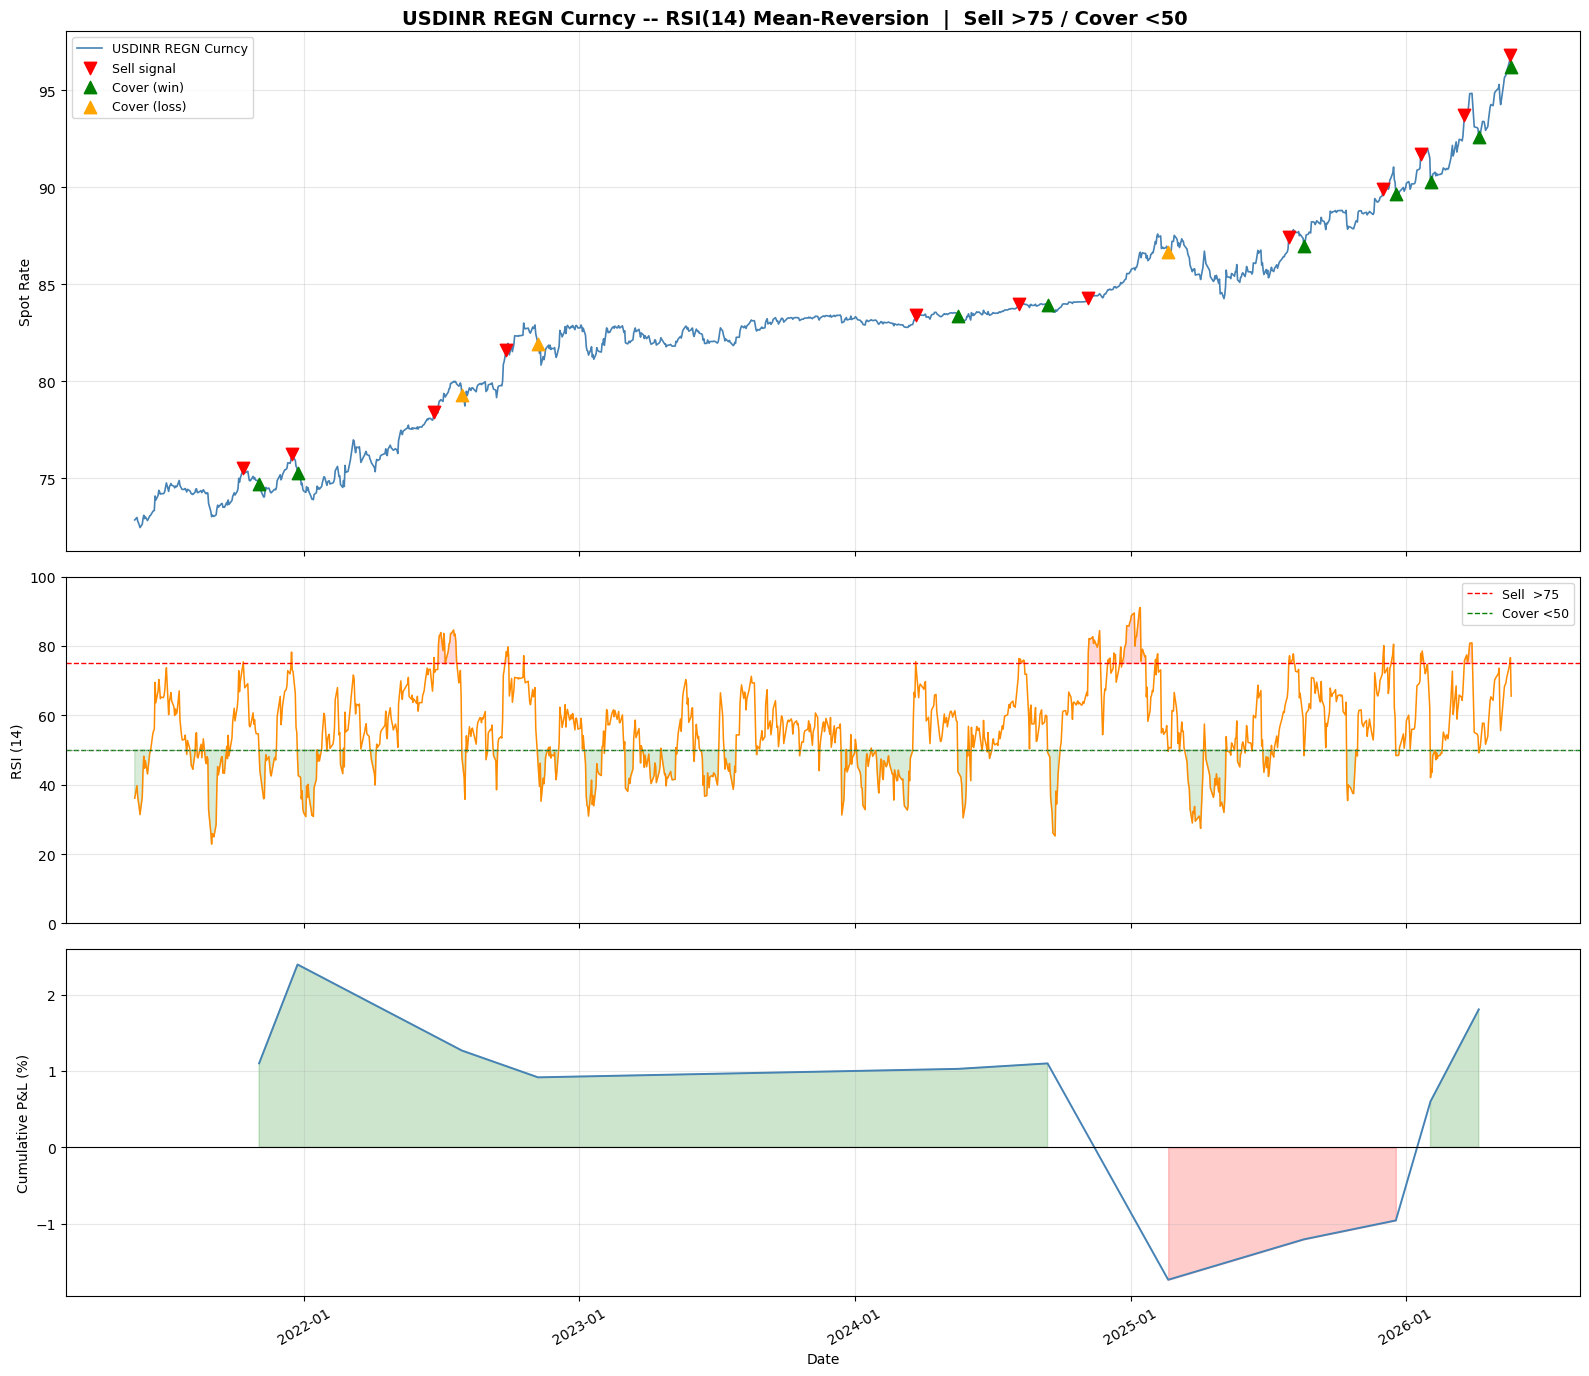

In [43]:
fig, axes = plt.subplots(3, 1, figsize=(16, 14), sharex=True,
                          gridspec_kw={'height_ratios': [3, 2, 2]})
fig.suptitle(f'{SECURITY} -- RSI({RSI_PERIOD}) Mean-Reversion  |  Sell >{SELL_THRESH} / Cover <{COVER_THRESH}',
             fontsize=14, fontweight='bold')

ax1 = axes[0]
ax1.plot(df.index, df['Close'], color='steelblue', lw=1.2, label=SECURITY)
if len(tdf):
    wins  = tdf[tdf['success'] == True]
    loses = tdf[tdf['success'] == False]
    ax1.scatter(tdf['entry_date'],  tdf['entry_price'],  marker='v', color='red',    s=80, zorder=5, label='Sell signal')
    ax1.scatter(wins['exit_date'],  wins['exit_price'],  marker='^', color='green',  s=80, zorder=5, label='Cover (win)')
    ax1.scatter(loses['exit_date'], loses['exit_price'], marker='^', color='orange', s=80, zorder=5, label='Cover (loss)')
ax1.set_ylabel('Spot Rate')
ax1.legend(fontsize=9)
ax1.grid(alpha=0.3)

ax2 = axes[1]
ax2.plot(df.index, df['RSI'], color='darkorange', lw=1.1)
ax2.axhline(SELL_THRESH,  color='red',   lw=1.0, ls='--', label=f'Sell  >{SELL_THRESH}')
ax2.axhline(COVER_THRESH, color='green', lw=1.0, ls='--', label=f'Cover <{COVER_THRESH}')
ax2.axhline(50,           color='grey',  lw=0.8, ls=':')
ax2.fill_between(df.index, df['RSI'], SELL_THRESH,  where=df['RSI'] > SELL_THRESH,  alpha=0.15, color='red')
ax2.fill_between(df.index, df['RSI'], COVER_THRESH, where=df['RSI'] < COVER_THRESH, alpha=0.15, color='green')
ax2.set_ylim(0, 100)
ax2.set_ylabel(f'RSI ({RSI_PERIOD})')
ax2.legend(fontsize=9)
ax2.grid(alpha=0.3)

ax3 = axes[2]
if len(closed):
    cum = closed.set_index('exit_date')['pnl_pct'].cumsum()
    ax3.plot(cum.index, cum.values, color='steelblue', lw=1.4)
    ax3.fill_between(cum.index, cum.values, 0, where=cum.values >= 0, alpha=0.2, color='green')
    ax3.fill_between(cum.index, cum.values, 0, where=cum.values <  0, alpha=0.2, color='red')
    ax3.axhline(0, color='black', lw=0.8)
ax3.set_ylabel('Cumulative P&L (%)')
ax3.set_xlabel('Date')
ax3.grid(alpha=0.3)
ax3.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## 7  --  Trade-by-Trade Detail

In [44]:
display_cols = ['entry_date','exit_date','entry_price','exit_price',
                'entry_rsi','exit_rsi','pnl_pct','duration_days','success']
styled = (
    closed[display_cols]
    .style
    .format({'entry_price': '{:.4f}', 'exit_price': '{:.4f}',
             'entry_rsi': '{:.1f}',   'exit_rsi': '{:.1f}',
             'pnl_pct': '{:+.3f}%'})
    .applymap(lambda v: 'color: green' if v is True else
                        'color: red'   if v is False else '',
              subset=['success'])
    .bar(subset=['pnl_pct'], color=['#d65f5f', '#5fba7d'], align='zero')
)
styled

,entry_date,exit_date,entry_price,exit_price,entry_rsi,exit_rsi,pnl_pct,duration_days,success
0,2021-10-12 00:00:00,2021-11-02 00:00:00,75.5150,74.6850,75.4,49.4,+1.099%,21,True
1,2021-12-15 00:00:00,2021-12-23 00:00:00,76.2312,75.2450,78.2,47.3,+1.294%,8,True
2,2022-06-22 00:00:00,2022-07-29 00:00:00,78.3862,79.2688,76.7,48.0,-1.126%,37,False
3,2022-09-26 00:00:00,2022-11-07 00:00:00,81.6250,81.9113,78.3,46.4,-0.351%,42,False
4,2024-03-22 00:00:00,2024-05-17 00:00:00,83.4250,83.3325,75.5,43.7,+0.111%,56,True
5,2024-08-06 00:00:00,2024-09-13 00:00:00,83.9575,83.8975,76.4,49.3,+0.071%,38,True
6,2024-11-06 00:00:00,2025-02-20 00:00:00,84.2800,86.6663,78.2,49.6,-2.831%,106,False
7,2025-07-30 00:00:00,2025-08-19 00:00:00,87.4250,86.9625,75.5,48.4,+0.529%,20,True
8,2025-12-02 00:00:00,2025-12-19 00:00:00,89.8750,89.6525,76.5,48.4,+0.248%,17,True
9,2026-01-21 00:00:00,2026-02-03 00:00:00,91.7012,90.2725,77.8,42.0,+1.558%,13,True


## 8  --  P&L Distribution

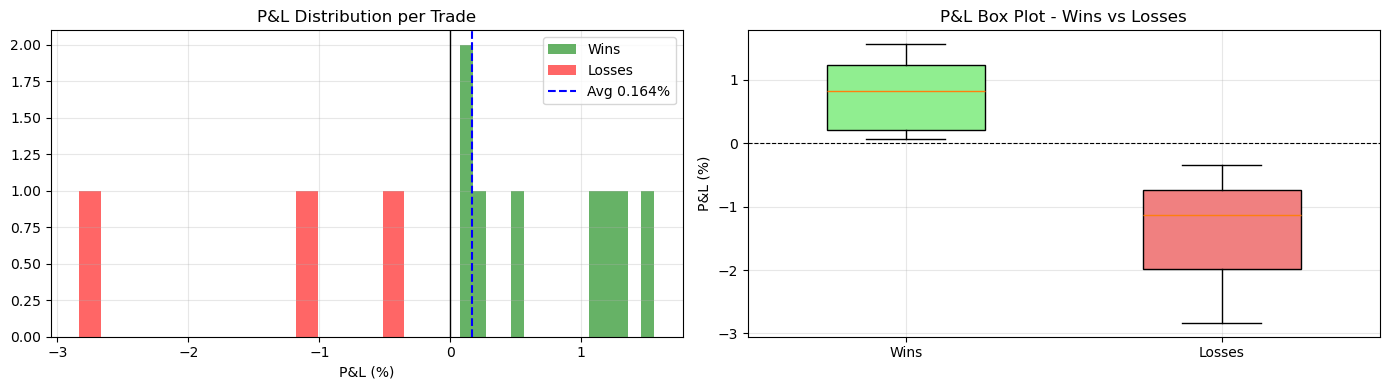

In [45]:
if len(closed):
    wins_data   = closed.loc[closed['success'],  'pnl_pct']
    losses_data = closed.loc[~closed['success'], 'pnl_pct']

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    ax = axes[0]
    ax.hist(wins_data,   bins=15, color='green', alpha=0.6, label='Wins')
    ax.hist(losses_data, bins=15, color='red',   alpha=0.6, label='Losses')
    ax.axvline(0,       color='black', lw=1)
    ax.axvline(avg_pnl, color='blue',  lw=1.5, ls='--', label=f'Avg {avg_pnl:.3f}%')
    ax.set_title('P&L Distribution per Trade')
    ax.set_xlabel('P&L (%)')
    ax.legend()
    ax.grid(alpha=0.3)

    ax = axes[1]
    bp = ax.boxplot([wins_data.values, losses_data.values], labels=['Wins', 'Losses'],
                    patch_artist=True, widths=0.5)
    bp['boxes'][0].set_facecolor('#90ee90')
    bp['boxes'][1].set_facecolor('#f08080')
    ax.axhline(0, color='black', lw=0.8, ls='--')
    ax.set_title('P&L Box Plot - Wins vs Losses')
    ax.set_ylabel('P&L (%)')
    ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()